In [21]:
#Task1
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Dataset Loaded Successfully")

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop("Cabin", axis=1)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nDuplicate Records Before Removal")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicate Records After Removal")
print(df.duplicated().sum())

df["Age_Group"] = pd.cut(df["Age"],bins=[0, 12, 18, 35, 60, 100],labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

df["Family_Size"] = df["SibSp"] + df["Parch"] + 1

print("\nNew Columns Created")
print(df[["Age", "Age_Group", "Family_Size"]].head())

survival_rate = df["Survived"].mean() * 100

print("\nOverall Survival Rate")
print(f"{survival_rate:.2f}%")

print("\nSurvival Rate By Gender")
print(df.groupby("Sex")["Survived"].mean() * 100)

print("\nSurvival Rate By Passenger Class")
print(df.groupby("Pclass")["Survived"].mean() * 100)

print("\nAge Group Distribution")
print(df["Age_Group"].value_counts())

print("\nFamily Size Statistics")
print(df["Family_Size"].describe())

numeric_df = df.select_dtypes(include=np.number)

print("\nCorrelation Matrix")
print(numeric_df.corr())

df.to_csv("titanic_cleaned.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

df_check = pd.read_csv("titanic_cleaned.csv")

print("\nDataset Shape:")
print(df_check.shape)

print("\nColumn Names:")
print(df_check.columns.tolist())

print("\nFirst 5 Rows:")
print(df_check.head())

print("\nMissing Values:")
print(df_check.isnull().sum())

print("\nDataset Loaded Back Successfully!")


Dataset Loaded Successfully

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

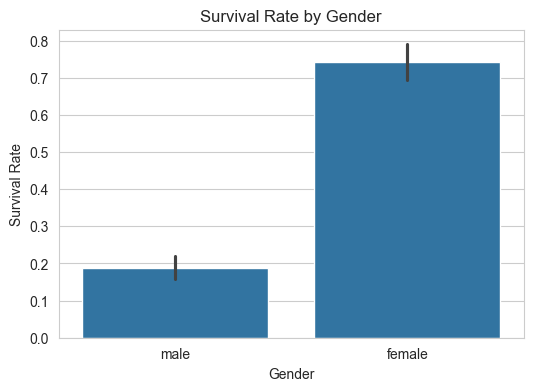

In [22]:
#Task2
#Bar Chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.savefig("chart1_survival_by_gender.png")
plt.show()

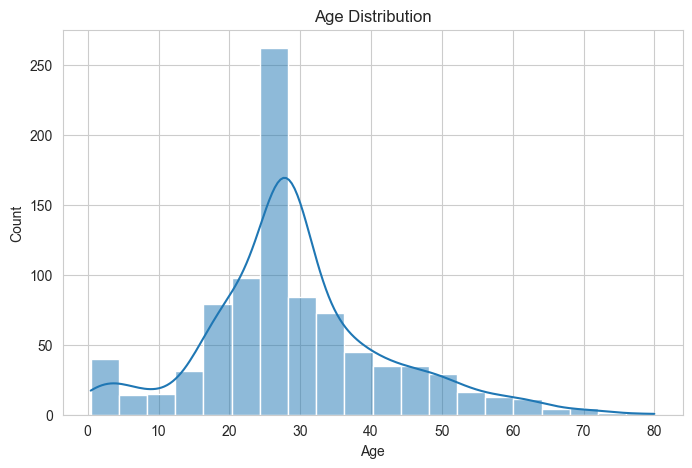

In [23]:
#Histogram – Age Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("chart2_age_distribution.png")
plt.show()

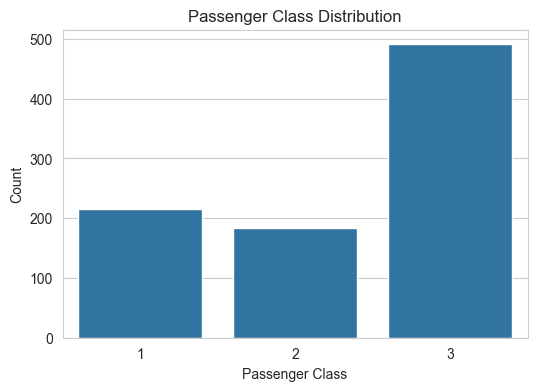

In [24]:
#Pie Chart – Passenger Class Breakdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.savefig("chart3_class_distribution.png")
plt.show()

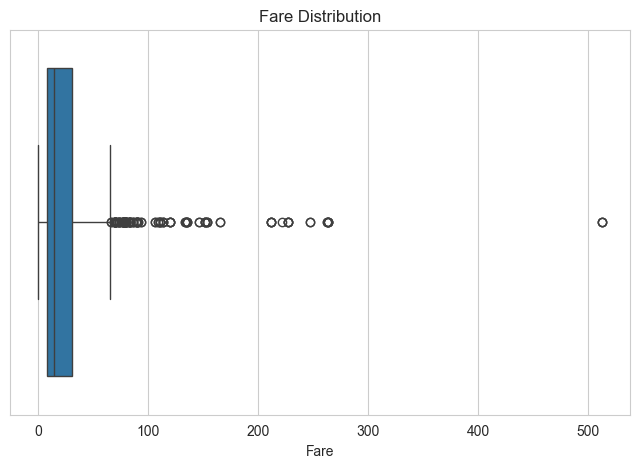

In [25]:
#Seaborn Boxplot – Fare by Passenger Class
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Distribution")
plt.savefig("chart4_fare_boxplot.png")
plt.show()

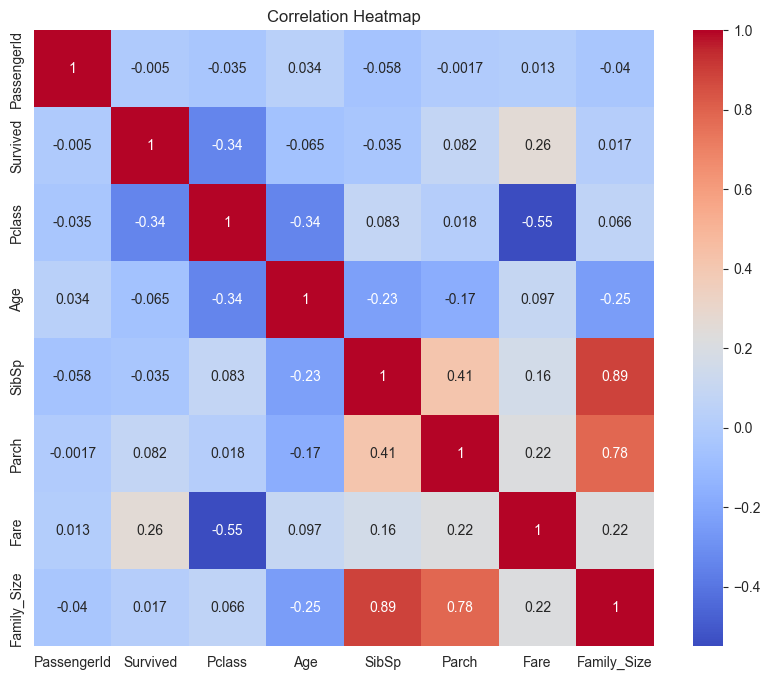

In [26]:
#Seaborn Heatmap – Correlation Matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("chart5_correlation_heatmap.png")
plt.show()

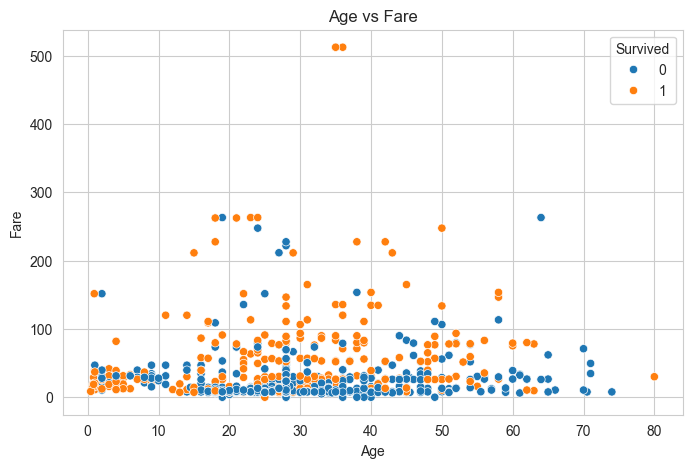

In [27]:
#Seaborn Scatter Plot – Age vs Fare
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.savefig("chart6_age_vs_fare_scatter.png")
plt.show()

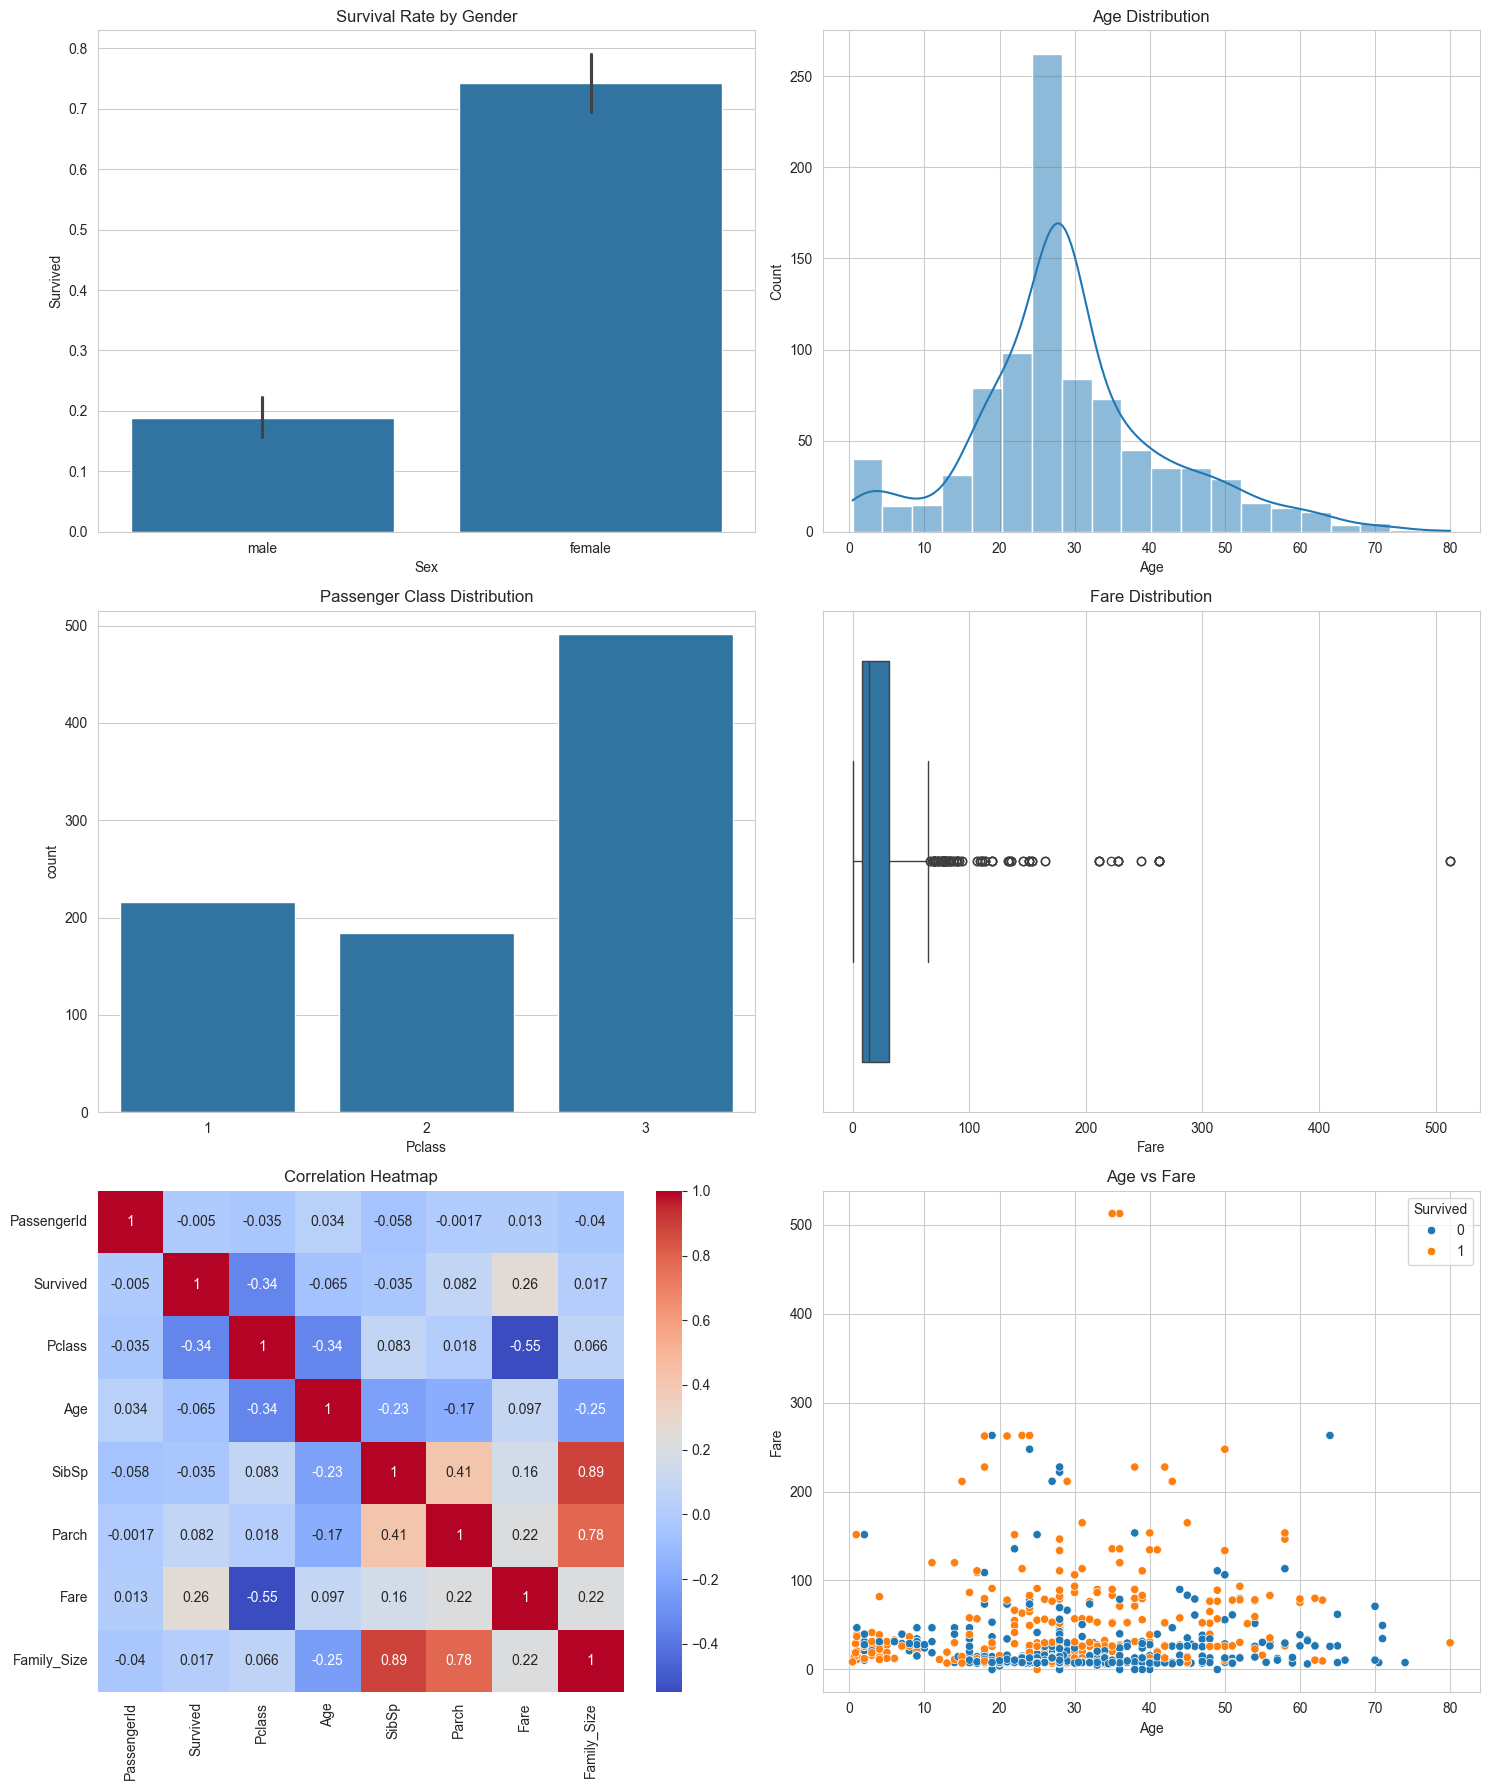

Dashboard saved


In [18]:
#Dashboard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_cleaned.csv")

numeric_df = df.select_dtypes(include=["int64", "float64"])

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

sns.barplot(x="Sex", y="Survived", data=df, ax=axes[0,0])
axes[0,0].set_title("Survival Rate by Gender")

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title("Age Distribution")

sns.countplot(x="Pclass", data=df, ax=axes[1,0])
axes[1,0].set_title("Passenger Class Distribution")

sns.boxplot(x=df["Fare"], ax=axes[1,1])
axes[1,1].set_title("Fare Distribution")

sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",ax=axes[2,0])
axes[2,0].set_title("Correlation Heatmap")

sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df,ax=axes[2,1])
axes[2,1].set_title("Age vs Fare")

plt.tight_layout()

plt.savefig("dashboard_titanic.png", dpi=300)

plt.show()

print("Dashboard saved")